# 3.시각화 라이브러리 : plotly




- https://plotly.com/python/

- **plotly**는 인터랙티브한 그래프를 그릴 수 있는 라이브러리이다.

-  확대/축소, 호버링(마우스 올리기), 데이터 포인트 선택 등 동적 인터랙션이 가능한 그래프를 만들 수 있다.

- 인터랙티브한 그래프를 html로 저장하기 용이하다.

In [ ]:
# %pip install plotly notebook nbformat statsmodels --upgrade

## **3.1. 기본 문법**


```
fig = px.그래프종류(data_frame=데이터, x=X축 컬럼, y=Y축 컬럼, color=범례 컬럼, title=제목,
                 labels=dict(X축 컬럼=X축 라벨, Y축 컬럼=Y축 라벨),
                 width=그래프 가로길이, height=그래프 세로길이, text_auto=True/False)
fig.show()
```



- 주요 매개변수
    - data_frame : 데이터프레임
    - x : X축 컬럼
    - y : Y축 컬럼
    - color : 범례 컬럼
    - title : 제목
    - labels : dict(X축 컬럼=X축 라벨, Y축 컬럼=Y축 라벨)
    - width : 그래프 가로길이
    - height : 그래프 세로길이
    - text_auto : True/False


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = sns.load_dataset('penguins')
df.head()

In [ ]:
df.info()

In [ ]:
# 결측치
df.dropna(inplace=True)
df.info()

In [5]:
df_groupby = df.groupby('species')[['body_mass_g']].mean().reset_index()
df_groupby

,species,body_mass_g
0,Adelie,3706.164384
1,Chinstrap,3733.088235
2,Gentoo,5092.436975


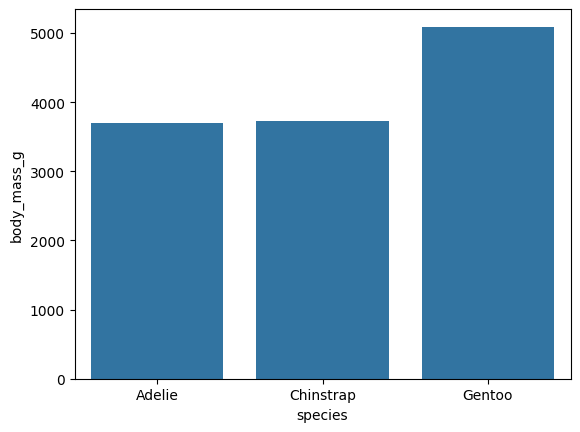

In [6]:
# seaborn barplot
sns.barplot(data=df_groupby, x='species', y='body_mass_g')
plt.show()

In [ ]:
# plotly로 그리기
fig = px.bar(df_groupby, x='species', y='body_mass_g')
fig

In [ ]:
df_groupby1 = df.groupby(['island','sex'])[['body_mass_g']].mean().reset_index()
df_groupby1

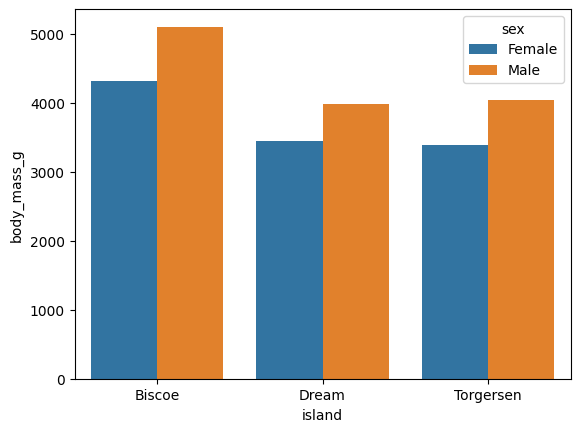

In [13]:
# seaborn
sns.barplot(data=df_groupby1, x='island', y='body_mass_g', hue='sex')
plt.show()

In [ ]:
# plotly
fig = px.bar(df_groupby1, x='island', y='body_mass_g', color='sex')
fig

In [16]:
fig = px.bar(df_groupby1,
             x='island',
             y='body_mass_g',
             color='sex', 
             barmode='group',
             width=700,
             height=500,
             text_auto='.0d',
             labels=dict(body_mass_g='몸무게(g)', island='섬', sex='성별'))
fig.show()

## **3.2. 스타일 설정하기**

- template : 템플릿명

- color_discrete_sequence : 컬러맵명 #범주형 데이터

- color_continuous_scale : 컬러맵명 #연속형 데이터



**1) 템플릿 적용**

In [ ]:
template = ['ggplot2', 'seaborn', 'simple_white', 'plotly', 'plotly_white', 'plotly_dark']

for temp in template:
    fig = px.bar(df_groupby1,
                x='island',
                y='body_mass_g',
                color='sex',
                title=f'템플릿:{temp}',
                barmode='group',
                width=700,
                height=500,
                text_auto='.0d',
                labels=dict(body_mass_g='몸무게(g)', island='섬', sex='성별'),
                template=temp)
    fig.show()

**2) 컬러맵 적용**

In [18]:
fig = px.colors.sequential.swatches_continuous()
fig.show()

In [19]:
fig = px.colors.qualitative.swatches()
fig.show()

In [20]:
color_map = [px.colors.qualitative.Pastel1, px.colors.qualitative.Safe, px.colors.qualitative.Antique]

for cm in color_map:
    fig = px.bar(data_frame=df_groupby1,
                 x='sex',
                 y='body_mass_g',
                 color='island',
                 barmode='group',
                 color_discrete_sequence=cm)
    fig.show()

## **3.3. HTML 파일로 저장하기**

- fig.write_html(파일경로 및 파일명)



In [22]:
fig = px.scatter(data_frame=df,
                 x='bill_length_mm',
                 y='bill_depth_mm',
                 color='flipper_length_mm',
                 width=700,
                 height=500,
                 template='plotly_white')

fig.show()
fig.write_html('test.html')

## **3.4. 유형별 그래프 그리기**

### **3.4.1. 선그래프**

- px.line(data_frame=데이터, x=X축 컬럼, y=Y축 컬럼, color=색)




In [ ]:
flights = sns.load_dataset('flights')
flights

In [ ]:
# 10월 탑승객
oct_flights = flights[flights['month']=='Oct']

fig = px.line(
    data_frame=oct_flights,
    x='year',
    y='passengers'
)

fig.show()

In [25]:
# 모든 월 탑승객
fig = px.line(
    data_frame=flights,
    x='year',
    y='passengers',
    color='month'
)

fig.show()

### **3.4.2. 산점도**

- px.scatter(data_frame=데이터, x=X축 컬럼, y=Y축 컬럼, color=색, trendline='ols') #trendline은 추세선 추가


In [26]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [28]:
fig = px.scatter(data_frame=df,
                 x='bill_length_mm',
                 y='bill_depth_mm',
                 color='sex'
                 )
fig.show()

In [29]:
fig = px.scatter(data_frame=df,
                 x='bill_length_mm',
                 y='bill_depth_mm',
                 color='island',
                 symbol='sex'
                 )
fig.show()

In [30]:
fig = px.scatter(data_frame=df,
                 x='bill_length_mm',
                 y='bill_depth_mm',
                 color='sex',
                 facet_col='island')
fig.show()

### **3.4.3.히스토그램**

- px.histogram(data_frame=데이터, x=X축 컬럼, color=색)

In [31]:
fig = px.histogram(data_frame=df,
                   x='flipper_length_mm',
                   template='plotly_white')
fig.show()

### **3.4.4.상자그림**

- px.box(data_frame=데이터, x=X축 컬럼, y=Y축 컬럼, color=색)

In [ ]:
fig = px.box(data_frame=df,
             x='body_mass_g')
fig.show()

In [ ]:
fig = px.box(data_frame=df,
             x='body_mass_g',
             y='species',
             color='sex',
             template='plotly_white')
fig.show()

### **3.4.5. 막대 그래프**

- px.bar(data_frame=데이터, x=X축 컬럼, y=Y축 컬럼, color=색, barmode='group') #쌓아서 올리지 않으면 barmode = 'group'을 추가한다

In [ ]:
titanic = sns.load_dataset('titanic')
titanic.head()

In [ ]:
titanic_gb = titanic.groupby(['sex', 'class'])[['survived']].mean().reset_index()
titanic_gb

In [ ]:
fig = px.bar(data_frame=titanic_gb,
             x='class',
             y='survived',
             color='sex')
fig.show()

In [38]:
fig = px.bar(data_frame=titanic_gb,
             x='class',
             y='survived',
             color='sex',
             barmode='group',
             text_auto='.2f')
fig.show()

### **3.4.6. 히트맵**

- px.imshow(데이터, text_auto=텍스트포맷, color_continuous_scale=컬러맵)



In [ ]:
titanic_corr = titanic[['survived','pclass', 'age', 'fare', 'sibsp']].corr()
titanic_corr

In [ ]:
fig = px.imshow(titanic_corr,
                text_auto='.2f',
                color_continuous_scale='YlOrBr')
fig.show()

In [44]:
titanic_pivot = pd.pivot_table(data=titanic, 
                               index='sex', 
                               columns='class', 
                               values='survived', 
                               aggfunc='mean')
titanic_pivot

class,First,Second,Third
sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


In [43]:
fig = px.imshow(titanic_pivot,
                text_auto='.2f',
                color_continuous_scale='Purples')
fig.show()

### **3.4.7. 파이차트**

- px.pie(data_frame=데이터, values=값, names=라벨)


In [49]:
tips = px.data.tips()
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [50]:
fig = px.pie(tips,
             values='tip',
             names='day')
fig.show()